In [1]:
import os
import sys
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shutil
import re

project_dir = 'D:/2022 Multi-Species Standard Study'

In [2]:
##
## Read in PepQuant data
##

# concatenate "-pepQuant.tsv" results from each submission subdirectories
all_df = pd.DataFrame()
for subdir, dirs, files in os.walk(project_dir):
    for file in files:
        
        #print(os.path.join(subdir, file))
        if "pepQuant" in file:
            
            print(os.path.join(subdir, file))
            if file.endswith(".tsv"):
                df = pd.read_table(os.path.join(subdir, file))
            elif file.endswith(".txt"):
                df = pd.read_table(os.path.join(subdir, file))
            elif file.endswith(".csv"):
                df = pd.read_csv(os.path.join(subdir, file))
            
            # add a column to denote the submission
            #submission_num = str(file).split("-")[0]  # FIX!
            submission_num = re.search(r'\d{2}', file)
            if submission_num:
                submission_num = submission_num.group()
            else:
                submission_num = ''
            df["Submission"] = submission_num
            
            # drop any empty columns that were read in
            df = df.dropna(axis='columns', how='all')  
            
            # Convert all "Quantity" columns to numeric if they are not already
            quantity_columns = [col for col in df.columns if 'Quantity' in col]
            df[quantity_columns] = df[quantity_columns].apply(pd.to_numeric, errors='coerce')
            
            # add a column to denote the file itself, since some sites submitted multiple results
            df["File"] = file
            
            # do some minor column/header cleaning
            ## Site 07 mislabeled columns as follows -- corrected below
            if submission_num == '07':
                df = df.rename(columns={"PG.Organisms": "Species",
                                        "EG.PrecursorId": "Peptide"})
                
            ## Site 09 mislabeled "Peptide" as "Pepide" -- corrected below
            if submission_num == '09':
                df = df.rename(columns={"Pepide": "Peptide"})

            ## Site 09 reported individual technical replicates -- averaged below
            if submission_num == '09':
                df['Sample A Quantity'] = df[['Sample A_R1 Quantity', 
                                              'Sample A_R2 Quantity',
                                              'Sample A_R3 Quantity']].mean(axis=1)
                df['Sample B Quantity'] = df[['Sample B_R1 Quantity', 
                                              'Sample B_R2 Quantity',
                                              'Sample B_R3 Quantity']].mean(axis=1)
                df['Sample C Quantity'] = df[['Sample C_R1 Quantity', 
                                              'Sample C_R2 Quantity',
                                              'Sample C_R3 Quantity',
                                              'Sample C_R4 Quantity']].mean(axis=1)
                df = df[['Peptide', 'Species', 
                         'Sample A Quantity', 'Sample B Quantity', 'Sample C Quantity',
                         'File', 'Submission']]
            
            ## Site 14 reported "Peptide" as "Sequence" -- corrected below
            if submission_num == '14':
                df = df.rename(columns={"Sequence": "Peptide"})
            
            ## Site 01 and 07 seem to report precursors instead of peptides -- collapsing via averaging
            if (submission_num == '01') or (submission_num == '07'):
                
                # Extract just the peptide sequence from the precursor string
                df['Peptide'] = df['Peptide'].str.extract(r'([A-Za-z]+)')
                
                # Average the precuror quantities into a peptide quantity
                df = df.groupby(['Peptide', 'Species', 'Submission', 'File'], as_index=False).mean()         

            # now add this submission to the rest
            all_df = pd.concat([all_df, df], ignore_index=False)


# standardize the Species column
species_map = {'BOS TAURUS': 'COW',
               'HOMO SAPIENS': 'HUMAN',
               'SALVELINUS NAMAYCUSH': 'TROUT',
               'BOVIN': 'COW',
               'SALNM': 'TROUT'}
all_df['Species'] = all_df['Species'].str.upper()
all_df['Species'] = all_df['Species'].str.strip()
all_df['Species'] = all_df['Species'].replace(species_map)

all_df.to_csv("H:/My Drive/career/proj/sprg/results/all_submissions_pepQuant.csv", index=False)
all_df

D:/2022 Multi-Species Standard Study\01\01-pepQuant.tsv
D:/2022 Multi-Species Standard Study\02\02-pepQuant.csv
D:/2022 Multi-Species Standard Study\03\03-pepQuant.tsv
D:/2022 Multi-Species Standard Study\04\04-pepQuant.tsv
D:/2022 Multi-Species Standard Study\05\05-pepQuant.tsv
D:/2022 Multi-Species Standard Study\06\06-pepQuant.tsv
D:/2022 Multi-Species Standard Study\07\07-pepQuant.tsv
D:/2022 Multi-Species Standard Study\07\07-pepQuant_ShortGrad.tsv
D:/2022 Multi-Species Standard Study\08\08-pepQuant.tsv
D:/2022 Multi-Species Standard Study\09\09-pepQuant.tsv
D:/2022 Multi-Species Standard Study\10\10-Fusion_pepQuant.tsv
D:/2022 Multi-Species Standard Study\10\10-QEx_pepQuant.tsv
D:/2022 Multi-Species Standard Study\11\11-pepQuant.tsv
D:/2022 Multi-Species Standard Study\12\12-pepQuant.tsv
D:/2022 Multi-Species Standard Study\13\13-pepQuant.tsv
D:/2022 Multi-Species Standard Study\14\14_pepQuant_sPRG_lumos_DIA_1x8mzStag_3x4mzGPFlibrary.txt
D:/2022 Multi-Species Standard Study\14\14

,Peptide,Species,Submission,File,Sample A Quantity,Sample B Quantity,Sample C Quantity,Sample B Quantity.1
0,AAAAPSSFQLLYDLK,COW,01,01-pepQuant.tsv,157.697022,199.811279,563.886780,NaN
1,AAAAPSSFQLLYDLKLPVEDKIR,COW,01,01-pepQuant.tsv,92.983559,137.256561,292.546539,NaN
2,AAAITSDILETLGR,COW,01,01-pepQuant.tsv,87.786659,381.369568,809.646179,NaN
3,AAANMDLM,COW,01,01-pepQuant.tsv,128.475571,304.646393,626.192932,NaN
4,AAAYNLVQR,COW,01,01-pepQuant.tsv,251.163925,509.693909,1075.693848,NaN
...,...,...,...,...,...,...,...,...
9848,TPLSESGITQR,COW,41,41-pepQuant.tsv,0.000000,0.000000,1.000000,NaN
9849,EMTDLTCR,COW,41,41-pepQuant.tsv,0.000000,2.000000,0.000000,NaN
9850,ILDVTVTIR,TROUT,41,41-pepQuant.tsv,0.000000,2.000000,1.000000,NaN
9851,VATVAMASPTSER,TROUT,41,41-pepQuant.tsv,1.000000,0.000000,0.000000,NaN


In [3]:
all_df[all_df["Submission"] == "14"]

,Peptide,Species,Submission,File,Sample A Quantity,Sample B Quantity,Sample C Quantity,Sample B Quantity.1
0,AAAAPSSFQLLYDLK,COW,14,14_pepQuant_sPRG_lumos_DIA_1x8mzStag_3x4mzGPFl...,611000.0,4850000.0,11000000.0,NaN
1,AAAEQIAVIAGCK,COW,14,14_pepQuant_sPRG_lumos_DIA_1x8mzStag_3x4mzGPFl...,248000.0,6820000.0,7890000.0,NaN
2,AAAEVNQDYGLDPK,MIXED,14,14_pepQuant_sPRG_lumos_DIA_1x8mzStag_3x4mzGPFl...,12400000.0,13100000.0,13100000.0,NaN
3,AAALAHLDR,COW,14,14_pepQuant_sPRG_lumos_DIA_1x8mzStag_3x4mzGPFl...,3570000.0,8410000.0,11300000.0,NaN
4,AAALQEGLR,COW,14,14_pepQuant_sPRG_lumos_DIA_1x8mzStag_3x4mzGPFl...,2320000.0,12100000.0,20000000.0,NaN
...,...,...,...,...,...,...,...,...
17357,YYVTIIDAPGHR,MIXED,14,14_pepQuant_sPRG_lumos_DIA_2x4mzStag_Prosit_li...,10000000.0,10000000.0,20000000.0,NaN
17358,YYWGGAYTR,TROUT,14,14_pepQuant_sPRG_lumos_DIA_2x4mzStag_Prosit_li...,5000000.0,4000000.0,5000000.0,NaN
17359,YYWGGAYTWDMAK,COW,14,14_pepQuant_sPRG_lumos_DIA_2x4mzStag_Prosit_li...,0.0,200000.0,200000.0,NaN
17360,YYWGGQYTWDMAK,HUMAN,14,14_pepQuant_sPRG_lumos_DIA_2x4mzStag_Prosit_li...,5000000.0,2000000.0,40000.0,NaN


,File,count
0,01-pepQuant.tsv,5115
1,02-pepQuant.csv,18729
2,03-pepQuant.tsv,3651
3,04-pepQuant.tsv,13680
4,05-pepQuant.tsv,1
5,06-pepQuant.tsv,6590
6,07-pepQuant.tsv,17507
7,07-pepQuant_ShortGrad.tsv,17390
8,08-pepQuant.tsv,1
9,09-pepQuant.tsv,6470


C:\Users\linds\AppData\Local\Temp\ipykernel_2500\3239419881.py:13: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar='sd'` for the same effect.

  g = sns.barplot(x='File', y='count', data=peptide_df, capsize=.1, ci="sd")


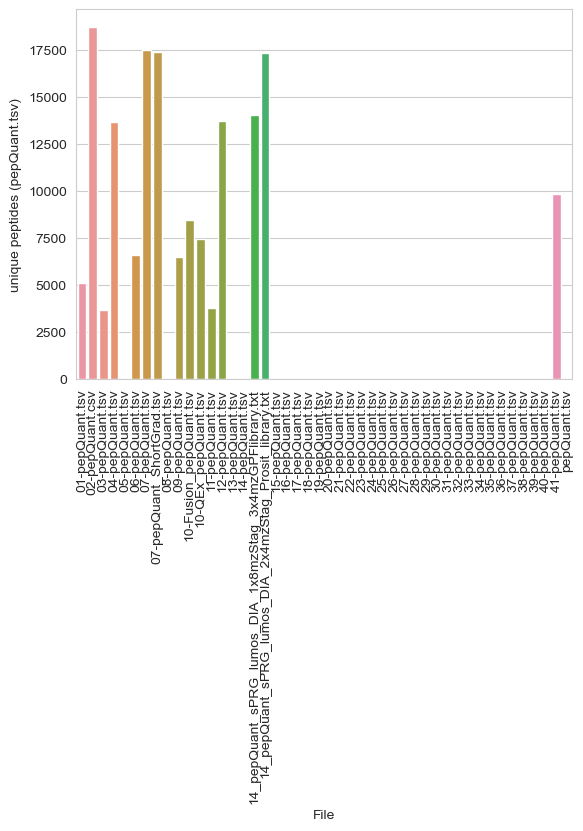

In [31]:
##
## Make a barplot of the detected peptides
##

peptide_df = all_df[['Peptide', 'File']].drop_duplicates()
peptide_df = peptide_df.groupby(['File']).agg(['count'])
peptide_df.columns = peptide_df.columns.droplevel(0)
peptide_df = peptide_df.reset_index()
display(peptide_df)

sns.set_style("whitegrid")
# Plot peptide detections per gradient length
g = sns.barplot(x='File', y='count', data=peptide_df, capsize=.1, ci="sd")

#sns.swarmplot(x='Species', y='count', data=peptide_df, color="0", alpha=.5)
g.set_xticklabels(g.get_xticklabels(), fontsize=10, rotation='vertical')
g.set(xlabel='File', ylabel='unique peptides (pepQuant.tsv)')
plt.show()